# 08 – Summary Statistics

This notebook provides a concise descriptive overview of the collected datasets for the Master's thesis.
It covers:
- **EC antitrust cases** collected from EUR-Lex
- **CJEU cases** collected via the EUR-Lex web service
- **Citation match datasets**: CJEU→EC, EC→EC, CJEU→CJEU

The goal is to evaluate the quality, coverage, and plausibility of the collected data.


## 1. Imports and Configuration

In [60]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

DATA_DIR = Path("data/processed")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)
print("Configuration loaded.")


Configuration loaded.


## 2. Load Datasets

In [61]:
def load_csv(path, **kwargs):
    p = Path(path)
    if not p.exists():
        print(f"  [MISSING] {p}")
        return pd.DataFrame()
    df = pd.read_csv(p, dtype=str, encoding="utf-8", **kwargs)
    print(f"  [OK] {p.name}: {len(df):,} rows, {df.shape[1]} columns")
    return df

print("Loading datasets...")
ec_master         = load_csv(DATA_DIR / "ec_antitrust_master.csv")
cjeu_cases        = load_csv(DATA_DIR / "cjeu_cases.csv")
cjeu_ec_matches   = load_csv(DATA_DIR / "cjeu_ec_case_matches.csv")
ec_ec_matches     = load_csv(DATA_DIR / "ec_ec_case_matches.csv")
cjeu_cjeu_matches = load_csv(DATA_DIR / "cjeu_cjeu_case_matches.csv")


Loading datasets...
  [OK] ec_antitrust_master.csv: 1,185 rows, 8 columns
  [OK] cjeu_cases.csv: 4,396 rows, 9 columns
  [OK] cjeu_ec_case_matches.csv: 673 rows, 14 columns
  [OK] ec_ec_case_matches.csv: 485 rows, 14 columns
  [OK] cjeu_cjeu_case_matches.csv: 6,784 rows, 17 columns


## 3. Classify CJEU Cases

CJEU cases collected in `cjeu_cases.csv` are classified into two groups based on their CELEX ID:
- **c_case**: Court of Justice cases (CELEX court code `CJ`, case number prefix `C-`)
- **t_case**: General Court / Court of First Instance cases (CELEX court code `TJ`/`FJ`, prefix `T-`/`F-`)

Note: Early CJEU cases without a letter prefix (so-called *old_cjeu*, e.g. `6/64`) do **not** appear
as a regular category in `cjeu_cases.csv`. They are detected separately from the citation match data.


In [62]:
_CELEX_RE = re.compile(r"^6(?P<year>\d{4})(?P<court>CJ|TJ|FJ)(?P<number>\d+)$", re.IGNORECASE)

def classify_cjeu_celex(celex_id):
    m = _CELEX_RE.match(str(celex_id).strip())
    if not m:
        return "other"
    court = m.group("court").upper()
    if court == "CJ":
        return "c_case"
    return "t_case"

if not cjeu_cases.empty:
    cjeu_cases["group"] = cjeu_cases["celex_id"].apply(classify_cjeu_celex)
    print("CJEU group distribution (from cjeu_cases.csv):")
    print(cjeu_cases["group"].value_counts().to_string())


CJEU group distribution (from cjeu_cases.csv):
group
other     2217
c_case    1185
t_case     994


## 4. Deduplicate Citation Pairs

In [63]:
def dedup_pairs(df, src_col, tgt_col):
    if df.empty:
        return pd.DataFrame(columns=[src_col, tgt_col])
    return df[[src_col, tgt_col]].drop_duplicates().reset_index(drop=True)

cjeu_ec_pairs   = dedup_pairs(cjeu_ec_matches,   "cjeu_celex_id",         "ec_case_number")
ec_ec_pairs     = dedup_pairs(ec_ec_matches,      "source_ec_case_number", "target_ec_case_number")
cjeu_cjeu_pairs = dedup_pairs(cjeu_cjeu_matches,  "source_celex_id",       "target_celex_id")

print(f"Unique CJEU->EC edges  : {len(cjeu_ec_pairs):,}")
print(f"Unique EC->EC edges    : {len(ec_ec_pairs):,}")
print(f"Unique CJEU->CJEU edges: {len(cjeu_cjeu_pairs):,}")


Unique CJEU->EC edges  : 673
Unique EC->EC edges    : 485
Unique CJEU->CJEU edges: 6,781


---
## Section 1 – Corpus Overview

This section reports the headline counts for all collected case datasets.
These numbers define the empirical basis of the thesis and allow a quick check
of whether the collection is complete and plausible.


In [64]:
n_ec   = len(ec_master)
n_cjeu = len(cjeu_cases)
grp_counts = cjeu_cases["group"].value_counts() if not cjeu_cases.empty else pd.Series(dtype=int)
n_c_case = int(grp_counts.get("c_case", 0))
n_t_case = int(grp_counts.get("t_case", 0))

corpus = pd.DataFrame({
    "Category": [
        "EC antitrust cases",
        "CJEU cases (total)",
        "  C cases (C-...)",
        "  T/F cases (T-/F-...)",
    ],
    "Count": [n_ec, n_cjeu, n_c_case, n_t_case],
})
display(corpus.set_index("Category"))


,Count
Category,
EC antitrust cases,1185
CJEU cases (total),4396
C cases (C-...),1185
T/F cases (T-/F-...),994


---
## Section 2 – Temporal Coverage

Statistics are computed over the **yearly case counts** (i.e. how many cases per year),
not over the raw year values.


In [65]:
def yearly_stats(year_series, label):
    yr = year_series.dropna().astype(int)
    if yr.empty:
        return None
    counts = yr.value_counts().sort_index()
    return pd.Series({
        "first year":      int(yr.min()),
        "last year":       int(yr.max()),
        "total cases":     int(yr.count()),
        "mean per year":   round(counts.mean(), 1),
        "median per year": round(counts.median(), 1),
        "min per year":    int(counts.min()),
        "max per year":    int(counts.max()),
    }, name=label)

rows = []

if not ec_master.empty and "date" in ec_master.columns:
    ec_master["year"] = pd.to_datetime(ec_master["date"], errors="coerce").dt.year
    s = yearly_stats(ec_master["year"], "EC cases")
    if s is not None:
        rows.append(s)

if not cjeu_cases.empty and "document_date" in cjeu_cases.columns:
    cjeu_cases["year"] = pd.to_datetime(cjeu_cases["document_date"], errors="coerce").dt.year
    for grp, lbl in [("c_case", "CJEU C cases"), ("t_case", "CJEU T/F cases")]:
        sub = cjeu_cases.loc[cjeu_cases["group"] == grp, "year"]
        s = yearly_stats(sub, lbl)
        if s is not None:
            rows.append(s)

if rows:
    display(pd.DataFrame(rows))
else:
    print("No date data available.")


,first year,last year,total cases,mean per year,median per year,min per year,max per year
EC cases,1964.00,2025.00,1185.00,19.80,16.50,1.00,66.00
CJEU C cases,1959.00,2025.00,1185.00,18.20,16.00,1.00,48.00
CJEU T/F cases,1990.00,2025.00,994.00,27.60,25.50,3.00,92.00


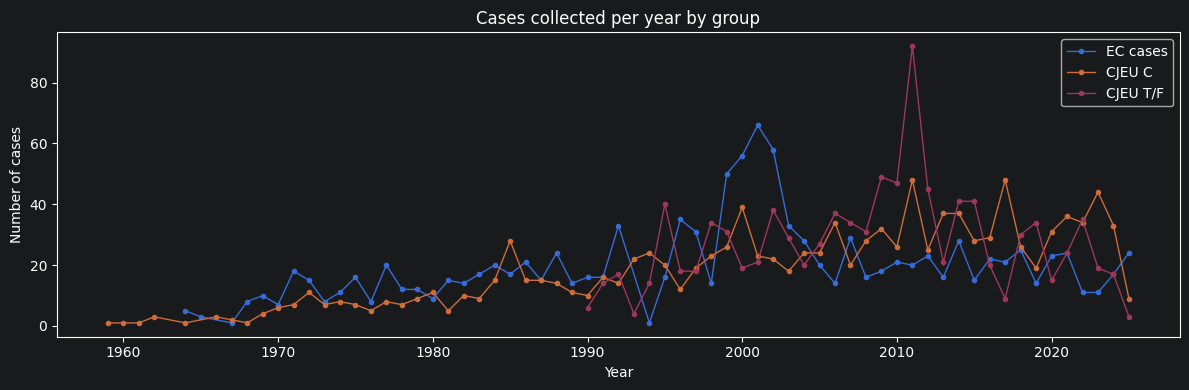

In [66]:
if HAS_MPL:
    yr_series = {}
    if not ec_master.empty and "year" in ec_master.columns:
        yr_series["EC cases"] = ec_master["year"].dropna().astype(int).value_counts().sort_index()
    if not cjeu_cases.empty and "year" in cjeu_cases.columns:
        for grp, lbl in [("c_case", "CJEU C"), ("t_case", "CJEU T/F")]:
            sub = cjeu_cases.loc[cjeu_cases["group"] == grp, "year"].dropna().astype(int)
            if not sub.empty:
                yr_series[lbl] = sub.value_counts().sort_index()

    if yr_series:
        fig, ax = plt.subplots(figsize=(12, 4))
        for lbl, s in yr_series.items():
            ax.plot(s.index, s.values, marker="o", markersize=3, linewidth=1, label=lbl)
        ax.set_title("Cases collected per year by group")
        ax.set_xlabel("Year")
        ax.set_ylabel("Number of cases")
        ax.legend()
        plt.tight_layout()
        plt.show()


---
## Section 3 – Citation Match Overview

This section summarises the three citation match datasets.
Each dataset records one citation relationship found in the text of a source document.

- **Raw rows**: total rows in the match file (one row per citation occurrence found)
- **Unique edges**: deduplicated source–target pairs (the actual citation relationships)
- **Unique sources**: number of distinct citing documents
- **Unique targets**: number of distinct cited documents



In [67]:
def match_summary(raw_df, pairs_df, src_col, tgt_col, label):
    if raw_df.empty:
        return {"Type": label, "Raw rows": 0, "Unique edges": 0,
                "Unique sources": 0, "Unique targets": 0, "Raw/edge ratio": None}
    return {
        "Type":           label,
        "Raw rows":       len(raw_df),
        "Unique edges":   len(pairs_df),
        "Unique sources": pairs_df[src_col].nunique() if not pairs_df.empty else 0,
        "Unique targets": pairs_df[tgt_col].nunique() if not pairs_df.empty else 0,
        "Raw/edge ratio": round(len(raw_df) / max(len(pairs_df), 1), 2),
    }

summary_rows = [
    match_summary(cjeu_ec_matches,   cjeu_ec_pairs,   "cjeu_celex_id",         "ec_case_number",        "CJEU->EC"),
    match_summary(ec_ec_matches,     ec_ec_pairs,     "source_ec_case_number", "target_ec_case_number", "EC->EC"),
    match_summary(cjeu_cjeu_matches, cjeu_cjeu_pairs, "source_celex_id",       "target_celex_id",       "CJEU->CJEU"),
]
display(pd.DataFrame(summary_rows).set_index("Type"))


,Raw rows,Unique edges,Unique sources,Unique targets,Raw/edge ratio
Type,,,,,
CJEU->EC,673,673,390,211,1.00
EC->EC,485,485,132,238,1.00
CJEU->CJEU,6784,6781,1688,871,1.00


---
## Section 4 – Citation Distributions

This section summarises how citations are distributed across source and target documents.

- **Citations made per source** (out-degree): how many unique targets does each source cite?
- **Citations received per target** (in-degree): how many unique sources cite each target?


In [68]:
def dist_stats(series, name):
    return pd.Series({
        "count":  int(series.count()),
        "mean":   round(series.mean(), 2),
        "median": round(series.median(), 2),
        "min":    int(series.min()),
        "max":    int(series.max()),
        "std":    round(series.std(), 2),
    }, name=name)

dist_rows = []

# CJEU->EC
if not cjeu_ec_pairs.empty:
    out = cjeu_ec_pairs.groupby("cjeu_celex_id").size()
    dist_rows.append(dist_stats(out, "CJEU->EC: citations made per source"))
    inn = cjeu_ec_pairs.groupby("ec_case_number").size()
    dist_rows.append(dist_stats(inn, "CJEU->EC: citations received per target"))

# EC->EC
if not ec_ec_pairs.empty:
    out = ec_ec_pairs.groupby("source_ec_case_number").size()
    dist_rows.append(dist_stats(out, "EC->EC: citations made per source"))
    inn = ec_ec_pairs.groupby("target_ec_case_number").size()
    dist_rows.append(dist_stats(inn, "EC->EC: citations received per target"))

# CJEU->CJEU
if not cjeu_cjeu_pairs.empty:
    out = cjeu_cjeu_pairs.groupby("source_celex_id").size()
    dist_rows.append(dist_stats(out, "CJEU->CJEU: citations made per source"))
    inn = cjeu_cjeu_pairs.groupby("target_celex_id").size()
    dist_rows.append(dist_stats(inn, "CJEU->CJEU: citations received per target"))

if dist_rows:
    display(pd.DataFrame(dist_rows))
else:
    print("No citation data available.")


,count,mean,median,min,max,std
CJEU->EC: citations made per source,390.00,1.73,1.00,1.00,11.00,1.56
CJEU->EC: citations received per target,211.00,3.19,2.00,1.00,43.00,4.56
EC->EC: citations made per source,132.00,3.67,2.00,1.00,19.00,3.59
EC->EC: citations received per target,238.00,2.04,1.00,1.00,12.00,1.71
CJEU->CJEU: citations made per source,1688.00,4.02,2.00,1.00,56.00,4.76
CJEU->CJEU: citations received per target,871.00,7.79,2.00,1.00,116.00,13.37


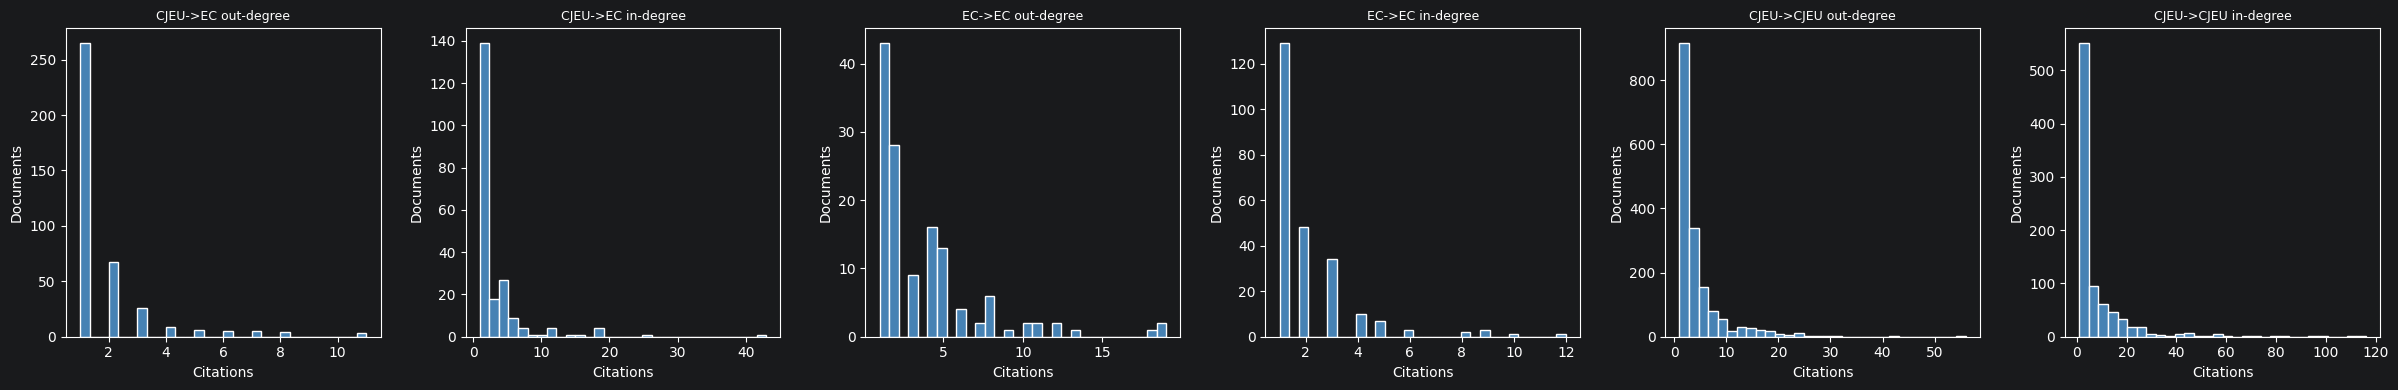

In [69]:
if HAS_MPL:
    plot_data = []
    if not cjeu_ec_pairs.empty:
        plot_data.append((cjeu_ec_pairs.groupby("cjeu_celex_id").size(),     "CJEU->EC out-degree"))
        plot_data.append((cjeu_ec_pairs.groupby("ec_case_number").size(),    "CJEU->EC in-degree"))
    if not ec_ec_pairs.empty:
        plot_data.append((ec_ec_pairs.groupby("source_ec_case_number").size(), "EC->EC out-degree"))
        plot_data.append((ec_ec_pairs.groupby("target_ec_case_number").size(), "EC->EC in-degree"))
    if not cjeu_cjeu_pairs.empty:
        plot_data.append((cjeu_cjeu_pairs.groupby("source_celex_id").size(), "CJEU->CJEU out-degree"))
        plot_data.append((cjeu_cjeu_pairs.groupby("target_celex_id").size(), "CJEU->CJEU in-degree"))

    if plot_data:
        n_plots = len(plot_data)
        fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
        if n_plots == 1:
            axes = [axes]
        for ax, (s, lbl) in zip(axes, plot_data):
            ax.hist(s.values, bins=30, color="steelblue", edgecolor="white")
            ax.set_title(lbl, fontsize=9)
            ax.set_xlabel("Citations")
            ax.set_ylabel("Documents")
        plt.tight_layout()
        plt.show()


---
## Section 5 – CJEU→CJEU: Citation Type Breakdown

This section analyses the **target case types** within the CJEU→CJEU citation dataset.
This is the correct place to detect and count **old CJEU cases** (cases without a letter prefix,
e.g. `6/64`), because those cases do not appear as a regular category in `cjeu_cases.csv`.

Target type classification is based on:
1. The `is_old_case_citation` flag in the match data (if available), or
2. Pattern-matching on `target_case_number` (numeric-only format like `6/64`), or
3. Fallback to CELEX ID pattern for C/T cases.

Source type is derived from the CELEX ID of the citing document.


In [70]:
def classify_target_type(row):
    """Classify a CJEU->CJEU citation target into old_cjeu / c_case / t_case / other."""
    # Use the is_old_case_citation flag if present
    flag = str(row.get("is_old_case_citation", "")).strip().lower()
    if flag in ("true", "1", "yes"):
        return "old_cjeu"
    # Fall back to pattern matching on target_case_number
    cn = str(row.get("target_case_number", "")).strip()
    if re.match(r"^\d+/\d+$", cn):
        return "old_cjeu"
    if cn.startswith("C-"):
        return "c_case"
    if cn.startswith("T-") or cn.startswith("F-"):
        return "t_case"
    # Fall back to CELEX ID pattern
    celex = str(row.get("target_celex_id", "")).strip()
    m = re.match(r"^6\d{4}(CJ|TJ|FJ)\d+$", celex, re.IGNORECASE)
    if m:
        court = m.group(1).upper()
        return "c_case" if court == "CJ" else "t_case"
    return "other"

def classify_source_type(celex_id):
    """Classify a CJEU source document by its CELEX ID."""
    m = re.match(r"^6\d{4}(CJ|TJ|FJ)\d+$", str(celex_id).strip(), re.IGNORECASE)
    if not m:
        return "other"
    court = m.group(1).upper()
    return "c_case" if court == "CJ" else "t_case"

tmp_edges = pd.DataFrame()

if not cjeu_cjeu_matches.empty:
    tmp = cjeu_cjeu_matches.copy()
    tmp["target_type"] = tmp.apply(classify_target_type, axis=1)
    tmp["source_type"] = tmp["source_celex_id"].apply(classify_source_type)

    # Deduplicate to unique edges before counting
    edge_cols = ["source_celex_id", "target_celex_id", "source_type", "target_type"]
    tmp_edges = tmp[edge_cols].drop_duplicates()

    print("Target type counts in CJEU->CJEU unique edges:")
    display(tmp_edges["target_type"].value_counts().rename("unique edges").to_frame())

    print("\nSource type × Target type cross-tabulation (unique edges):")
    crosstab = pd.crosstab(tmp_edges["source_type"], tmp_edges["target_type"], margins=True)
    display(crosstab)
else:
    print("No CJEU->CJEU match data available.")


Target type counts in CJEU->CJEU unique edges:


,unique edges
target_type,
old_cjeu,5264
t_case,1225
c_case,295



Source type × Target type cross-tabulation (unique edges):


target_type,c_case,old_cjeu,t_case,All
source_type,,,,
c_case,157,2069,239,2465
other,19,280,102,401
t_case,119,2915,884,3918
All,295,5264,1225,6784
